In [6]:
!pip install torch
import numpy as np
import pandas as pd

In [7]:
df= pd.read_csv("Powerplant_data.csv")

In [8]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [9]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [10]:
x=df.drop("PE",axis=1)
y=df["PE"]

In [11]:
y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [12]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(
    x,y, test_size=0.2, random_state=42
)

In [13]:
df.shape

(9568, 5)

In [14]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

In [15]:
x_test_scaled

array([[ 1.36255441,  0.24305848, -1.27798491, -1.04586379],
       [ 0.82147733,  1.36986442, -0.74695303,  0.31071896],
       [-0.247116  , -0.73708132,  1.92304887, -0.14668594],
       ...,
       [-0.67970645, -1.15815506, -0.31652036, -0.05697206],
       [ 1.33136451,  1.34463153, -0.87558808, -0.39000089],
       [-0.26474508, -0.26711887,  0.33984824,  1.14397069]])

In [16]:
import torch
import torch.nn as nn
x_train_tensor = torch.tensor(x_train_scaled, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32).view(-1,1)

x_test_tensor=torch.tensor(x_test_scaled, dtype=torch.float32)
y_test_tensor=torch.tensor(y_test.values, dtype=torch.float32).view(-1,1)

In [17]:
type(x_train_scaled)

numpy.ndarray

In [18]:
type(y_train)
y_train.shape

(7654,)

In [19]:
from torch.utils.data import TensorDataset,DataLoader
train_dataset = TensorDataset(x_train_tensor, y_train_tensor)
test_dataset = TensorDataset(x_test_tensor, y_test_tensor)

In [21]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [22]:
class ANN(nn.Module):
    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(x_train_tensor.shape[1], 6),
            nn.ReLU(),

            nn.Linear(6, 6),
            nn.ReLU(),

            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [23]:
import torch.optim as optim

model = ANN()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters())

In [24]:
train_losses = []
val_losses = []

best_val_loss = float("inf")

epochs = 100

for epoch in range(epochs):
    
    model.train()
    running_loss = 0.0 
    
    for xb, yb in train_loader:
        
        optimizer.zero_grad()
        
        outputs = model(xb) 
        loss = criterion(outputs, yb) 
        
        loss.backward() 
        optimizer.step() 
        
        running_loss += loss.item() 

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad(): 
        for xb, yb in test_loader:
            outputs = model(xb)
            loss = criterion(outputs, yb)
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    val_losses.append(epoch_val_loss)

    print(f"epoch {epoch+1}/{epochs} ==> train loss = {epoch_train_loss} & val loss = {epoch_val_loss}")

    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(), "best_model.pt")

epoch 1/100 ==> train loss = 205942.63033854167 & val loss = 203525.86354166668
epoch 2/100 ==> train loss = 195508.37200520834 & val loss = 182879.01197916668
epoch 3/100 ==> train loss = 161845.33984375 & val loss = 136954.79700520833
epoch 4/100 ==> train loss = 108497.95651041667 & val loss = 80797.16419270834
epoch 5/100 ==> train loss = 58635.09900716146 & val loss = 41203.06962890625
epoch 6/100 ==> train loss = 32057.3591796875 & val loss = 25879.24013671875
epoch 7/100 ==> train loss = 23362.671533203124 & val loss = 21050.776106770834
epoch 8/100 ==> train loss = 19834.524674479166 & val loss = 17986.141015625
epoch 9/100 ==> train loss = 16910.4318359375 & val loss = 15051.141813151042
epoch 10/100 ==> train loss = 13901.144014485677 & val loss = 12157.494978841145
epoch 11/100 ==> train loss = 11047.164329020183 & val loss = 9370.026774088541
epoch 12/100 ==> train loss = 8311.486279296874 & val loss = 6792.656693522135
epoch 13/100 ==> train loss = 5821.1759801228845 & val

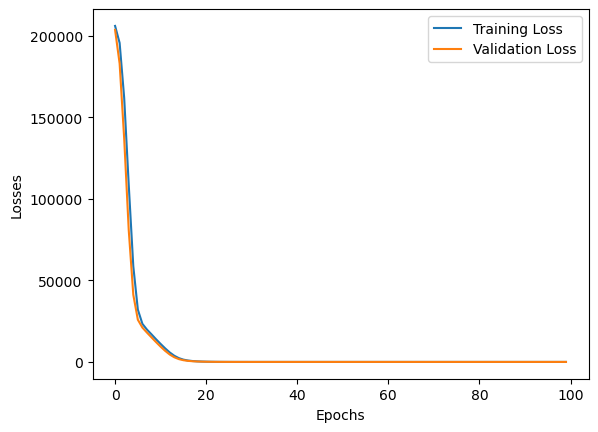

In [26]:
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "Training Loss": train_losses,
    "Validation Loss": val_losses
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [27]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [30]:
model.eval()

with torch.no_grad():
    train_preds = model(x_train_tensor)
    test_preds = model(x_test_tensor)

    train_mse_loss = criterion(train_preds, y_train_tensor)
    test_mse_loss = criterion(test_preds, y_test_tensor)

print("Training MSE:", train_mse_loss.item())
print("Testing MSE:", test_mse_loss.item())

Training MSE: 20.614452362060547
Testing MSE: 18.904727935791016


In [31]:
from sklearn.metrics import r2_score

print("r^2 score =", r2_score(y_test, test_preds))

r^2 score = 0.9339328530925413


In [32]:
predicted_df = pd.DataFrame(test_preds.numpy(), columns=["Predicted Values"])
actual_df = pd.DataFrame(y_test.values, columns=["Actual Values"])

pd.concat([predicted_df, actual_df], axis=1)

,Predicted Values,Actual Values
0,435.237549,433.27
1,436.853088,438.16
2,460.782898,458.42
3,475.879059,480.82
4,434.787994,441.41
...,...,...
1909,451.402405,456.70
1910,431.536438,438.04
1911,467.675781,467.80
1912,430.930847,437.14
